# Brownbag essential cells (cross-sectional)

Self-contained notebook with the cells from the April 2026 chat that drive the brownbag story:
- Per-ROI volume: individual deviation from bootstrapped control 95% range
- Distance × RDM: independence test (ρ=−0.09, n.s.)
- RDM with volume covaried: key hits *strengthen*, so volume does not explain RDM

Sample: 22 OTC patients (11 LH-intact, 11 RH-intact), 38 TD controls.


## Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist, spearmanr, linregress

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv')
MNI_CSV = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

_info_df = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
SUB_CODES = {row['sub']: (row['code'] if pd.notna(row['code']) and row['code'] != ''
                          else row['sub'].replace('sub-', ''))
             for _, row in _info_df.drop_duplicates('sub').iterrows()}

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})


## Load data

In [2]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls → first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients → last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')


Controls: 38
OTC patients: 22


## Helpers and constants

In [3]:
def crawford(x, c):
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
ALL_ROIS_FLAT = [r for cat in ALL_ROIS for r in ALL_ROIS[cat]]
roi_labels_flat = [r.replace('_', ' ').replace('pSTG liu', 'pSTG') for r in ALL_ROIS_FLAT]
cat_of = {r: cat for cat, rs in ALL_ROIS.items() for r in rs}
CAT_COLOR = {'face':'#cc0066', 'house':'#009900', 'object':'#0077cc', 'word':'#ff8800'}

def vol_per_sub(df, sub, roi, hemi):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)] \
          .drop_duplicates(subset=['subject_id'])
    if not len(m): return np.nan
    v = m['volume'].iloc[0]
    return v if v > 0 else np.nan


## 1. Per-ROI volume: individual deviation from control 95% range

For each ROI × surgery side, build the bootstrapped 95% range of the control distribution and count how many patients fall outside it.

**Brownbag use:** the 5/11 and 4/11 numbers for object_LOC and object_pF in LH-intact patients.


=== Patients outside bootstrapped 95% control range (log10 volume) ===
     group           roi    cat  n_tested  ctrl_median  ctrl_lo  ctrl_hi  n_below  n_above  pct_below
LH (R-res)      face_FFA   face        11         2.89     1.85     3.16        1        3       9.09
LH (R-res)      face_STS   face        11         2.34     0.90     3.48        2        0      18.18
LH (R-res)     house_PPA  house        11         3.38     2.71     3.74        1        0       9.09
LH (R-res)     house_TOS  house        11         3.43     2.43     3.96        1        0       9.09
LH (R-res)    object_LOC object        11         4.19     3.90     4.40        5        1      45.45
LH (R-res)     object_pF object        11         3.43     2.55     3.66        4        0      36.36
LH (R-res)     word_VWFA   word        10         2.95     0.46     3.49        0        1       0.00
LH (R-res)      word_STG   word         9         1.98     0.33     3.32        0        0       0.00
LH (R-res) 

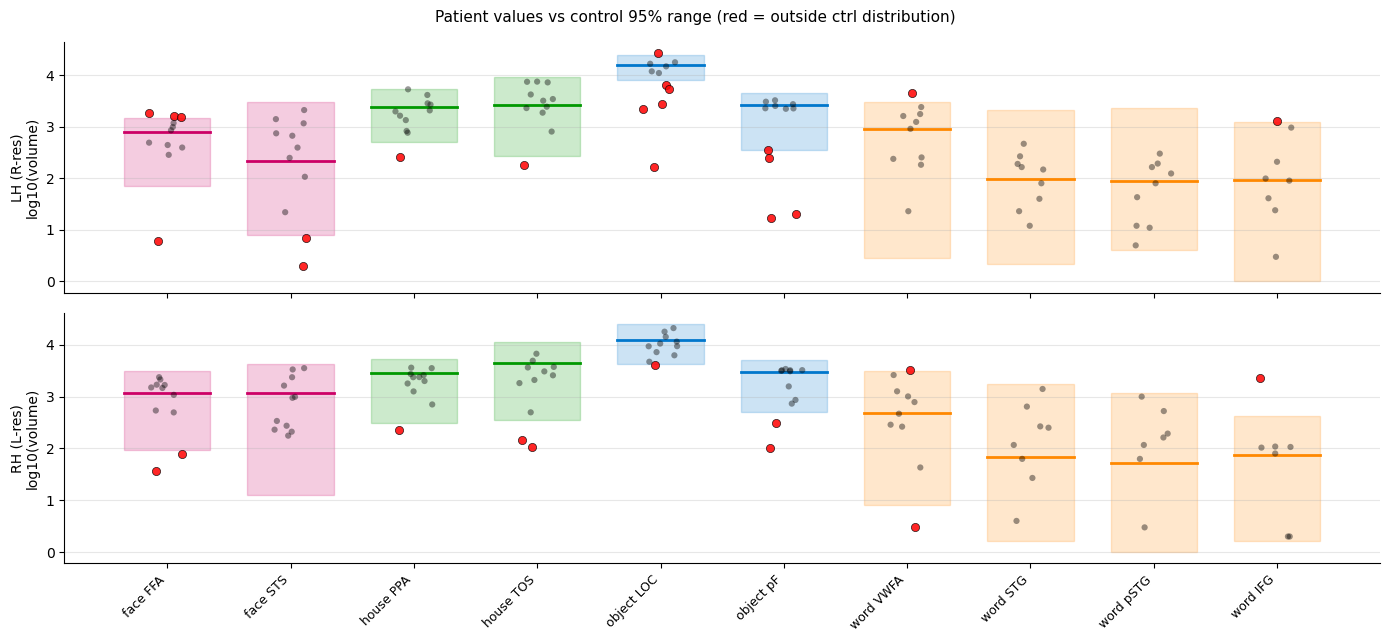

In [4]:
# ── Volume: patients outside bootstrapped 95% control range ─────────────────
N_BOOT = 10000
rng = np.random.RandomState(42)

def ctrl_ci(ct_vals, n_boot=N_BOOT, ci=95):
    """Bootstrap percentile CI on the control distribution."""
    ct_vals = ct_vals[~np.isnan(ct_vals)]
    if len(ct_vals) < 3: return np.nan, np.nan, np.nan
    lo_q, hi_q = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_los = np.empty(n_boot); boot_his = np.empty(n_boot)
    for b in range(n_boot):
        s = rng.choice(ct_vals, size=len(ct_vals), replace=True)
        boot_los[b] = np.percentile(s, lo_q)
        boot_his[b] = np.percentile(s, hi_q)
    return np.median(ct_vals), np.median(boot_los), np.median(boot_his)

rows = []
for intact, label in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for roi in ALL_ROIS_FLAT:
        ct = np.array([vol_per_sub(ctrl_le, s, roi, intact) for s in ctrl_subs])
        ct = ct[~np.isnan(ct)]
        if len(ct) < 3: continue
        ct_log = np.log10(ct)
        med, lo, hi = ctrl_ci(ct_log)
        n_below = n_above = n_tested = 0
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            n_tested += 1
            lv = np.log10(v)
            if lv < lo:   n_below += 1
            elif lv > hi: n_above += 1
        rows.append({
            'group': label, 'roi': roi, 'cat': cat_of[roi],
            'n_tested': n_tested,
            'ctrl_median': med, 'ctrl_lo': lo, 'ctrl_hi': hi,
            'n_below': n_below, 'n_above': n_above,
            'pct_below': 100*n_below/n_tested if n_tested else np.nan,
        })

ci_df = pd.DataFrame(rows)
print('=== Patients outside bootstrapped 95% control range (log10 volume) ===')
print(ci_df.to_string(index=False, float_format='%.2f'))

# Plot: ctrl 95% band + patient dots (red if outside)
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
for ax, (intact, label) in zip(axes, [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]):
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for j, roi in enumerate(ALL_ROIS_FLAT):
        sub_row = ci_df[(ci_df['group']==label) & (ci_df['roi']==roi)]
        if not len(sub_row): continue
        lo = sub_row['ctrl_lo'].iloc[0]; hi = sub_row['ctrl_hi'].iloc[0]
        med = sub_row['ctrl_median'].iloc[0]
        ax.add_patch(plt.Rectangle((j-0.35, lo), 0.7, hi-lo,
                                    facecolor=CAT_COLOR[cat_of[roi]], alpha=0.2,
                                    edgecolor=CAT_COLOR[cat_of[roi]], lw=1))
        ax.plot([j-0.35, j+0.35], [med, med], color=CAT_COLOR[cat_of[roi]], lw=2)
        for sub in pt_subs:
            v = vol_per_sub(pt_le, sub, roi, intact)
            if np.isnan(v): continue
            lv = np.log10(v)
            outside = lv < lo or lv > hi
            ax.scatter(j + rng.uniform(-0.15, 0.15), lv,
                       s=35 if outside else 20,
                       color='red' if outside else 'black',
                       alpha=0.85 if outside else 0.4, zorder=3,
                       edgecolor='black' if outside else 'none', linewidth=0.5)
    ax.set_ylabel(f'{label}\nlog10(volume)', fontsize=10)
    ax.set_xticks(range(len(ALL_ROIS_FLAT)))
    ax.set_xticklabels(roi_labels_flat, rotation=45, ha='right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Patient values vs control 95% range (red = outside ctrl distribution)', fontsize=11)
plt.tight_layout()
plt.show()


## 2. Distance × RDM independence

Per-patient, per-ROI: does Euclidean distance from ctrl centroid predict representational distinctiveness?

**Brownbag use:** ρ=−0.09 overall, n.s. — distance and RDM are independent.


In [5]:
# ── Does distance predict RDM? Per-patient, per-ROI ─────────────────────────
mni_df = pd.read_csv(MNI_CSV)

def dist_from_ctrl(sub_id, roi, hemi):
    """Euclidean distance of (sub_id, roi, hemi) peak from the ctrl centroid."""
    c = mni_df[mni_df['subject_id'].isin(ctrl_subs) &
               (mni_df['category']==roi) & (mni_df['hemi']==hemi)] \
        [['peak_x_mni','peak_y_mni']].dropna().values
    if len(c) < 3: return np.nan
    cen = c.mean(0)
    s = mni_df[(mni_df['subject_id']==sub_id) &
               (mni_df['category']==roi) & (mni_df['hemi']==hemi)] \
        [['peak_x_mni','peak_y_mni']].dropna().values
    if not len(s): return np.nan
    return np.linalg.norm(s[0] - cen)

rows = []
for sub in otc_subs:
    intact = pt_intact_hemi(sub)
    if intact is None: continue
    for roi in ALL_ROIS_FLAT:
        d = dist_from_ctrl(sub, roi, intact)
        r_row = pt_le[(pt_le['subject_id']==sub) & (pt_le['category']==roi) &
                      (pt_le['hemi']==intact)]
        if not len(r_row): continue
        rdm = r_row['liu_distinctiveness'].iloc[0]
        if np.isnan(d) or np.isnan(rdm): continue
        rows.append({'sub': sub, 'roi': roi, 'cat': cat_of[roi],
                     'intact': intact, 'dist': d, 'rdm': rdm})

pdf = pd.DataFrame(rows)
rho, p = spearmanr(pdf['dist'], pdf['rdm'])
print(f'All pairs (n={len(pdf)}): Spearman rho = {rho:+.3f}, p = {p:.3f}')

for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
    sub = pdf[pdf['intact']==intact]
    rho, p = spearmanr(sub['dist'], sub['rdm'])
    print(f'{label} (n={len(sub)}): rho = {rho:+.3f}, p = {p:.3f}')

print('\nPer-ROI × group:')
for intact, label in [('l','LH'),('r','RH')]:
    for roi in ALL_ROIS_FLAT:
        sub = pdf[(pdf['intact']==intact) & (pdf['roi']==roi)]
        if len(sub) < 5: continue
        rho, p = spearmanr(sub['dist'], sub['rdm'])
        flag = '*' if p < 0.05 else ''
        print(f'  {label} {roi:18s} n={len(sub):2d}  rho={rho:+.3f}  p={p:.3f} {flag}')


All pairs (n=220): Spearman rho = -0.092, p = 0.174
LH (R-res) (n=110): rho = -0.113, p = 0.239
RH (L-res) (n=110): rho = -0.126, p = 0.190

Per-ROI × group:
  LH face_FFA           n=11  rho=-0.018  p=0.958 
  LH face_STS           n=11  rho=+0.009  p=0.979 
  LH house_PPA          n=11  rho=+0.400  p=0.223 
  LH house_TOS          n=11  rho=+0.782  p=0.004 *
  LH object_LOC         n=11  rho=-0.082  p=0.811 
  LH object_pF          n=11  rho=+0.555  p=0.077 
  LH word_VWFA          n=11  rho=-0.164  p=0.631 
  LH word_STG           n=11  rho=+0.109  p=0.750 
  LH word_pSTG_liu      n=11  rho=-0.082  p=0.811 
  LH word_IFG           n=11  rho=+0.245  p=0.467 
  RH face_FFA           n=11  rho=-0.182  p=0.593 
  RH face_STS           n=11  rho=+0.282  p=0.401 
  RH house_PPA          n=11  rho=+0.564  p=0.071 
  RH house_TOS          n=11  rho=-0.255  p=0.450 
  RH object_LOC         n=11  rho=-0.155  p=0.650 
  RH object_pF          n=11  rho=-0.100  p=0.770 
  RH word_VWFA          n

## 3. RDM with volume covaried out

Regress RDM on log10(volume) across all subjects (patients + controls), take residuals, recompute Cohen's d on residuals. Does the RDM effect survive controlling for territory size?

**Brownbag use:** key hits *strengthen* after covarying — face_STS LH (−0.99 → −1.06), word_VWFA RH (+0.81 → +0.95). Volume does NOT explain the RDM effect.


In [6]:
# ── RDM with volume covaried out, matching Cell 34 sample ───────────────────
def get_d_rdm_covaried_v2(intact, roi):
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]

    # Full-sample d (matches the headline Cohen's d)
    ct_rdm = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)] \
             ['liu_distinctiveness'].dropna().values
    pt_rdm = pt_le[(pt_le['subject_id'].isin(pt_subs)) & (pt_le['category']==roi) &
                   (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
    if len(ct_rdm) < 3 or len(pt_rdm) < 2: return np.nan, np.nan
    d_raw = (pt_rdm.mean() - ct_rdm.mean()) / \
            np.sqrt((pt_rdm.var(ddof=1) + ct_rdm.var(ddof=1)) / 2)

    # Paired (rdm, vol) per subject for regression
    rows = []
    for src_le, subs, group in [(ctrl_le, ctrl_subs, 'ctrl'), (pt_le, pt_subs, 'pt')]:
        for sub in subs:
            r = src_le[(src_le['subject_id']==sub) & (src_le['category']==roi) &
                       (src_le['hemi']==intact)]
            if not len(r): continue
            rdm = r['liu_distinctiveness'].iloc[0]
            v_row = r.drop_duplicates(subset=['subject_id'])
            v = v_row['volume'].iloc[0]
            if np.isnan(rdm) or np.isnan(v) or v <= 0: continue
            rows.append({'group': group, 'rdm': rdm, 'log_vol': np.log10(v)})
    df = pd.DataFrame(rows)
    if (df['group']=='ctrl').sum() < 3 or (df['group']=='pt').sum() < 2:
        return d_raw, np.nan

    slope, intercept, _, _, _ = linregress(df['log_vol'], df['rdm'])
    df['resid'] = df['rdm'] - (slope * df['log_vol'] + intercept)
    ct_r = df[df['group']=='ctrl']['resid'].values
    pt_r = df[df['group']=='pt']['resid'].values
    d_resid = (pt_r.mean() - ct_r.mean()) / \
              np.sqrt((pt_r.var(ddof=1) + ct_r.var(ddof=1)) / 2)
    return d_raw, d_resid

print(f'{"Group":12s} {"ROI":18s} {"d_raw":>8s} {"d_covaried":>12s}')
print('-'*55)
for intact, label in [('l','LH (R-res)'), ('r','RH (L-res)')]:
    for roi in ALL_ROIS_FLAT:
        d_raw, d_resid = get_d_rdm_covaried_v2(intact, roi)
        if np.isnan(d_raw): continue
        print(f'{label:12s} {roi:18s} {d_raw:+8.2f} {d_resid:+12.2f}')


Group        ROI                   d_raw   d_covaried
-------------------------------------------------------
LH (R-res)   face_FFA              -0.29        -0.34
LH (R-res)   face_STS              -0.99        -1.06
LH (R-res)   house_PPA             -0.47        -0.48
LH (R-res)   house_TOS             -0.14        -0.14
LH (R-res)   object_LOC            -0.04        +0.31
LH (R-res)   object_pF             +0.05        +0.48
LH (R-res)   word_VWFA             -0.14        -0.09
LH (R-res)   word_STG              -0.16        +0.31
LH (R-res)   word_pSTG_liu         +0.26        +0.55
LH (R-res)   word_IFG              -0.18        -0.10
RH (L-res)   face_FFA              +0.46        +0.45
RH (L-res)   face_STS              +0.18        +0.20
RH (L-res)   house_PPA             +0.44        +0.42
RH (L-res)   house_TOS             -0.10        -0.21
RH (L-res)   object_LOC            +0.10        -0.06
RH (L-res)   object_pF             -0.26        -0.05
RH (L-res)   word_VWFA    

## 4. Volume violin plot (per category × intact hemisphere)

Mirrors the original sum-selectivity violin layout but uses per-ROI `volume` (suprathreshold voxel count), aggregated within category as mean log10(volume).

**Brownbag use:** visual companion to the volume Cohen's d numbers; shows the object-loss effect for LH-intact patients in distribution form.


  face LH: n_pt=11, n_ct=38, t=-0.46, p=0.654, d=-0.21
  face RH: n_pt=11, n_ct=38, t=-0.34, p=0.740, d=-0.10
  house LH: n_pt=11, n_ct=38, t=-0.38, p=0.708, d=-0.13
  house RH: n_pt=11, n_ct=38, t=-1.58, p=0.136, d=-0.60
  object LH: n_pt=11, n_ct=38, t=-1.98, p=0.074, d=-1.12
  object RH: n_pt=11, n_ct=38, t=-2.13, p=0.053, d=-0.86
  word LH: n_pt=10, n_ct=36, t=-1.36, p=0.189, d=-0.41
  word RH: n_pt=10, n_ct=38, t=+1.41, p=0.171, d=+0.37


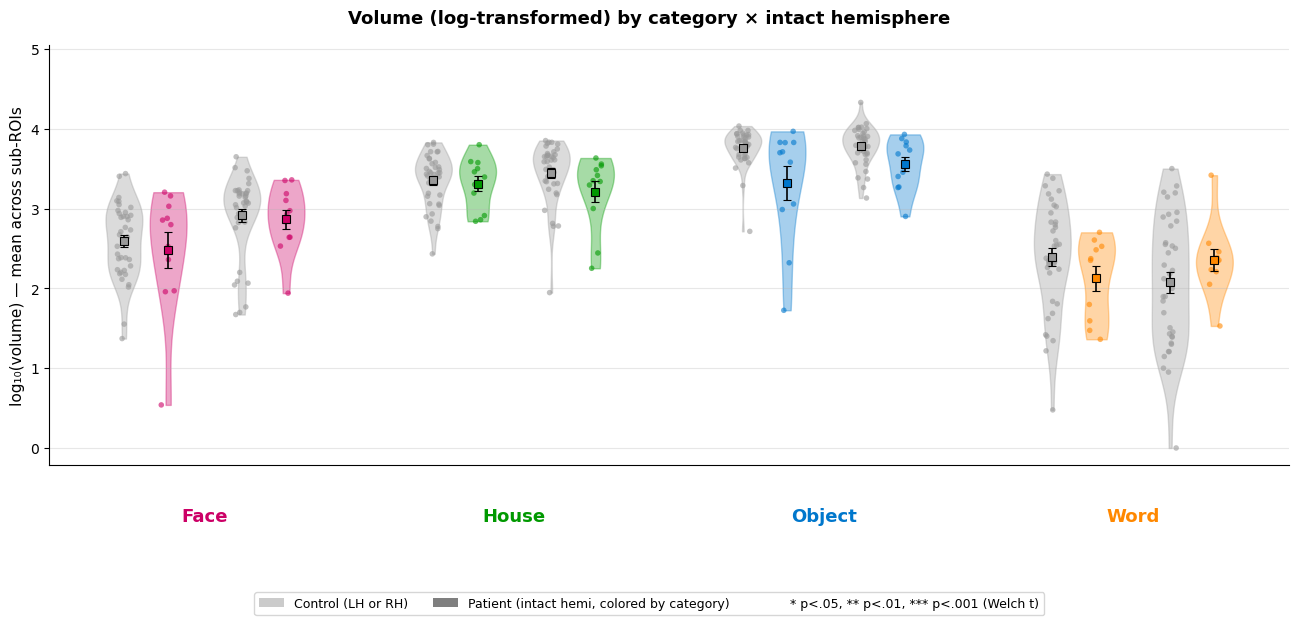

In [7]:
# ── Volume violin: per category × intact hemi ──────────────────────────────
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}
CTRL_COLOR = '#999999'

def collapse_log_volume(df, subject, category, hemi):
    sub = df[(df['subject_id'] == subject) &
             (df['category'].isin(CAT_SUBROIS[category])) &
             (df['hemi'] == hemi)].drop_duplicates(subset=['subject_id','category','hemi'])
    vals = sub['volume'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_volume(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_vol = build_table(ctrl_le, ctrl_subs)
pt_vol   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_vol['intact_hemi'] = pt_vol['subject_id'].map(intact_lookup)
pt_vol = pt_vol[
    ((pt_vol['intact_hemi'] == 'left')  & (pt_vol['hemi'] == 'l')) |
    ((pt_vol['intact_hemi'] == 'right') & (pt_vol['hemi'] == 'r'))
]

CATS_PANEL = ['face', 'house', 'object', 'word']
INTRA, INTER, CAT_GAP = 0.6, 1.0, 2.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(16, 6))
RNG = np.random.RandomState(42)
cat_centers = []

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS_SS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_vol[(ctrl_vol['category'] == cat) & (ctrl_vol['hemi'] == 'l')]['val'].values
    cr = ctrl_vol[(ctrl_vol['category'] == cat) & (ctrl_vol['hemi'] == 'r')]['val'].values
    pl = pt_vol[(pt_vol['category'] == cat) & (pt_vol['hemi'] == 'l')]['val'].values
    pr = pt_vol[(pt_vol['category'] == cat) & (pt_vol['hemi'] == 'r')]['val'].values

    groups = [
        (cl, positions[0], CTRL_COLOR),
        (pl, positions[1], cat_color),
        (cr, positions[2], CTRL_COLOR),
        (pr, positions[3], cat_color),
    ]

    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.1, 0.1, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=col, alpha=0.6, s=16, edgecolors='none', zorder=3)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    for pos_ctrl, pos_pt, pt_vals, ctrl_vals in [
        (positions[0], positions[1], pl, cl),
        (positions[2], positions[3], pr, cr),
    ]:
        pt_vals = pt_vals[~np.isnan(pt_vals)]
        ctrl_vals = ctrl_vals[~np.isnan(ctrl_vals)]
        if len(pt_vals) < 2 or len(ctrl_vals) < 3: continue
        t, p = stats.ttest_ind(pt_vals, ctrl_vals, equal_var=False)
        d = cohens_d(pt_vals, ctrl_vals)
        hemi_label = 'LH' if pos_pt == positions[1] else 'RH'
        print(f'  {cat} {hemi_label}: n_pt={len(pt_vals)}, n_ct={len(ctrl_vals)}, '
              f't={t:+.2f}, p={p:.3f}, d={d:+.2f}')
        if p >= 0.05: continue
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        y_top = max(np.max(pt_vals), np.max(ctrl_vals))
        y_br = y_top + 0.15
        ax.plot([pos_ctrl, pos_ctrl, pos_pt, pos_pt],
                [y_br, y_br + 0.05, y_br + 0.05, y_br],
                color='black', linewidth=1, clip_on=False)
        ax.text((pos_ctrl + pos_pt) / 2, y_br + 0.07,
                f'{sig}\nd={d:+.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks([])
ax.set_ylabel('log\u2081\u2080(volume) — mean across sub-ROIs', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.10, cat.title(), fontsize=13, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax + 0.5)

legend_elements = [
    Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control (LH or RH)'),
    Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi, colored by category)'),
    Line2D([0], [0], marker='None', linestyle='None',
           label='* p<.05, ** p<.01, *** p<.001 (Welch t)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Volume (log-transformed) by category \u00d7 intact hemisphere',
             fontsize=13, fontweight='bold', y=0.98)
plt.subplots_adjust(bottom=0.22, top=0.92)
plt.show()

  face LH: n_pt=11, n_ct=38, t=-0.34, p=0.739, d=-0.15
  face RH: n_pt=11, n_ct=38, t=-0.13, p=0.898, d=-0.04
  house LH: n_pt=11, n_ct=38, t=-0.27, p=0.789, d=-0.10
  house RH: n_pt=11, n_ct=38, t=-1.37, p=0.194, d=-0.55
  object LH: n_pt=11, n_ct=38, t=-1.98, p=0.073, d=-1.08
  object RH: n_pt=11, n_ct=38, t=-1.44, p=0.174, d=-0.63
  word LH: n_pt=10, n_ct=36, t=-1.02, p=0.322, d=-0.31
  word RH: n_pt=10, n_ct=38, t=+1.67, p=0.107, d=+0.45


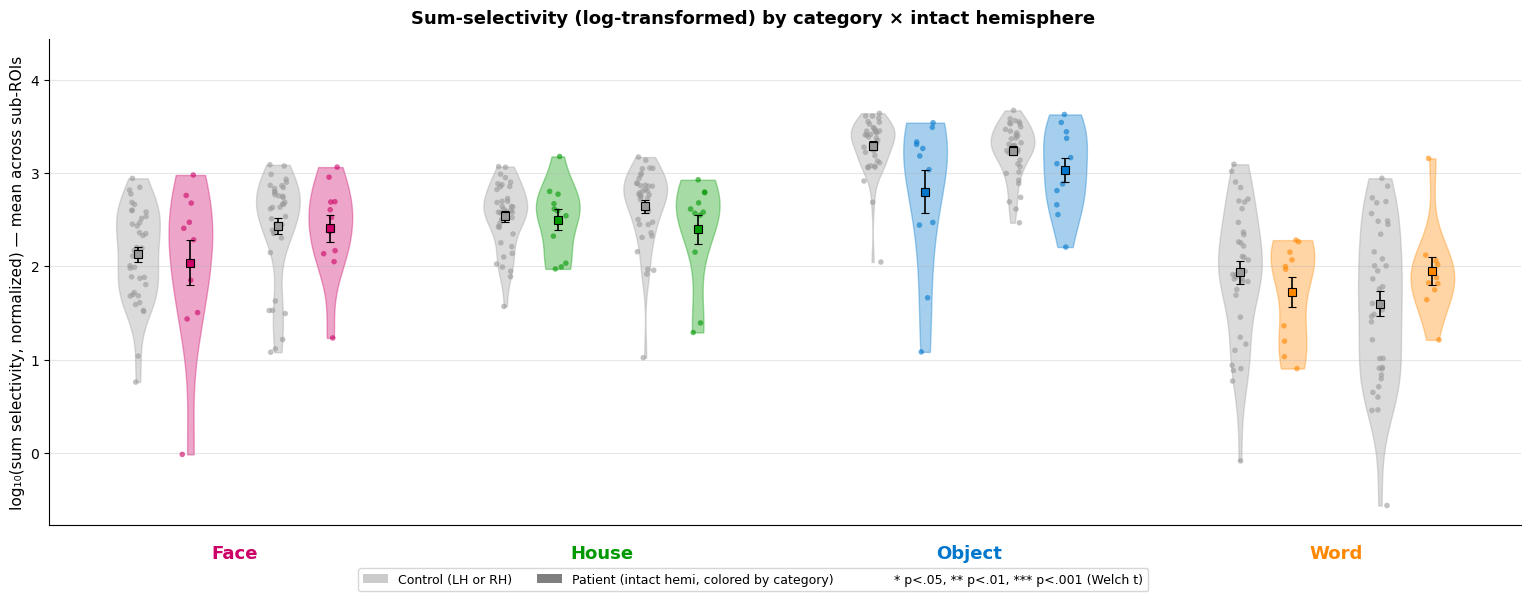

In [8]:
# ── Sum-selectivity violin: per category × intact hemi ─────────────────────
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}
CTRL_COLOR = '#999999'

def collapse_log_sumsel(df, subject, category, hemi):
    sub = df[(df['subject_id'] == subject) &
             (df['category'].isin(CAT_SUBROIS[category])) &
             (df['hemi'] == hemi)].drop_duplicates(subset=['subject_id','category','hemi'])
    vals = sub['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_sumsel(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_ss = build_table(ctrl_le, ctrl_subs)
pt_ss   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_ss['intact_hemi'] = pt_ss['subject_id'].map(intact_lookup)
pt_ss = pt_ss[
    ((pt_ss['intact_hemi'] == 'left')  & (pt_ss['hemi'] == 'l')) |
    ((pt_ss['intact_hemi'] == 'right') & (pt_ss['hemi'] == 'r'))
]

CATS_PANEL = ['face', 'house', 'object', 'word']
INTRA, INTER, CAT_GAP = 0.6, 1.0, 2.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(16, 6))
RNG = np.random.RandomState(42)
cat_centers = []

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS_SS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'l')]['val'].values
    cr = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'r')]['val'].values
    pl = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'l')]['val'].values
    pr = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'r')]['val'].values

    groups = [
        (cl, positions[0], CTRL_COLOR),
        (pl, positions[1], cat_color),
        (cr, positions[2], CTRL_COLOR),
        (pr, positions[3], cat_color),
    ]

    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.1, 0.1, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=col, alpha=0.6, s=16, edgecolors='none', zorder=3)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    for pos_ctrl, pos_pt, pt_vals, ctrl_vals in [
        (positions[0], positions[1], pl, cl),
        (positions[2], positions[3], pr, cr),
    ]:
        pt_vals = pt_vals[~np.isnan(pt_vals)]
        ctrl_vals = ctrl_vals[~np.isnan(ctrl_vals)]
        if len(pt_vals) < 2 or len(ctrl_vals) < 3: continue
        t, p = stats.ttest_ind(pt_vals, ctrl_vals, equal_var=False)
        d = cohens_d(pt_vals, ctrl_vals)
        hemi_label = 'LH' if pos_pt == positions[1] else 'RH'
        print(f'  {cat} {hemi_label}: n_pt={len(pt_vals)}, n_ct={len(ctrl_vals)}, '
              f't={t:+.2f}, p={p:.3f}, d={d:+.2f}')
        if p >= 0.05: continue
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        y_top = max(np.max(pt_vals), np.max(ctrl_vals))
        y_br = y_top + 0.08
        ax.plot([pos_ctrl, pos_ctrl, pos_pt, pos_pt],
                [y_br, y_br + 0.03, y_br + 0.03, y_br],
                color='black', linewidth=1, clip_on=False)
        ax.text((pos_ctrl + pos_pt) / 2, y_br + 0.05,
                f'{sig} d={d:+.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks([])
ax.set_ylabel('log\u2081\u2080(sum selectivity, normalized) — mean across sub-ROIs', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=13, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

# Tighter y-limits — use data range with small headroom
all_vals = np.concatenate([ctrl_ss['val'].dropna().values, pt_ss['val'].dropna().values])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
yrange = ymax - ymin
ax.set_ylim(ymin - 0.05 * yrange, ymax + 0.18 * yrange)

legend_elements = [
    Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control (LH or RH)'),
    Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi, colored by category)'),
    Line2D([0], [0], marker='None', linestyle='None',
           label='* p<.05, ** p<.01, *** p<.001 (Welch t)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, 0.0))

plt.suptitle('Sum-selectivity (log-transformed) by category \u00d7 intact hemisphere',
             fontsize=13, fontweight='bold', y=0.98)
plt.subplots_adjust(bottom=0.12, top=0.93, left=0.06, right=0.98)
plt.show()

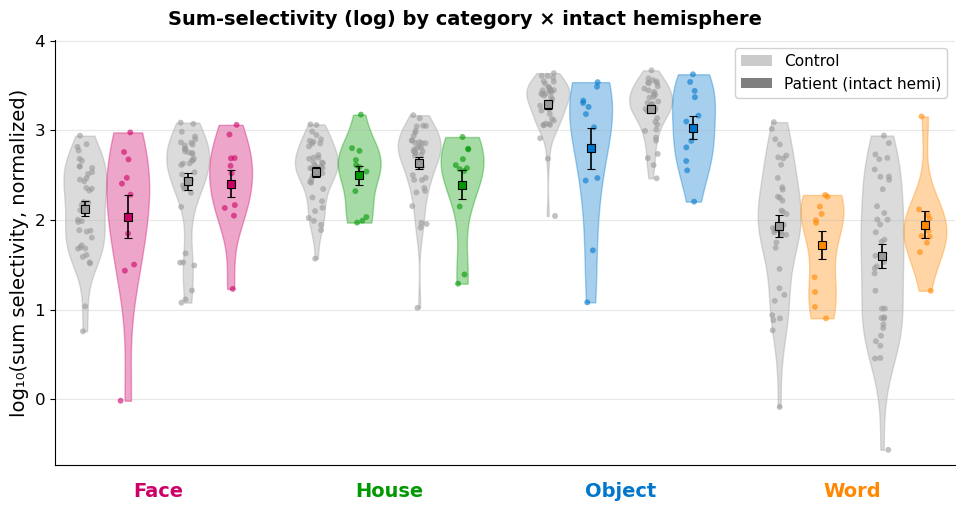

In [9]:
# ── Sum-selectivity violin: per category × intact hemi ─────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}
CTRL_COLOR = '#999999'

def collapse_log_sumsel(df, subject, category, hemi):
    sub = df[(df['subject_id'] == subject) &
             (df['category'].isin(CAT_SUBROIS[category])) &
             (df['hemi'] == hemi)].drop_duplicates(subset=['subject_id','category','hemi'])
    vals = sub['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_sumsel(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_ss = build_table(ctrl_le, ctrl_subs)
pt_ss   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_ss['intact_hemi'] = pt_ss['subject_id'].map(intact_lookup)
pt_ss = pt_ss[
    ((pt_ss['intact_hemi'] == 'left')  & (pt_ss['hemi'] == 'l')) |
    ((pt_ss['intact_hemi'] == 'right') & (pt_ss['hemi'] == 'r'))
]

CATS_PANEL = ['face', 'house', 'object', 'word']
INTRA, INTER, CAT_GAP = 0.5, 0.7, 1.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(10, 5))
RNG = np.random.RandomState(42)
cat_centers = []

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS_SS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'l')]['val'].values
    cr = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'r')]['val'].values
    pl = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'l')]['val'].values
    pr = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'r')]['val'].values

    groups = [
        (cl, positions[0], CTRL_COLOR),
        (pl, positions[1], cat_color),
        (cr, positions[2], CTRL_COLOR),
        (pr, positions[3], cat_color),
    ]

    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.09, 0.09, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=col, alpha=0.6, s=18, edgecolors='none', zorder=3)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

ax.set_xticks([])
ax.set_ylabel('log\u2081\u2080(sum selectivity, normalized)', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

total_width = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
ax.set_xlim(-0.35, total_width + 0.35)
ax.margins(x=0.005)

all_vals = np.concatenate([ctrl_ss['val'].dropna().values, pt_ss['val'].dropna().values])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
yrange = ymax - ymin
ax.set_ylim(ymin - 0.04 * yrange, ymax + 0.08 * yrange)

legend_elements = [
    Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control'),
    Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11,
          frameon=True, framealpha=0.9)

plt.suptitle('Sum-selectivity (log) by category × intact hemisphere',
             fontsize=14, fontweight='bold', y=0.99)
plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
plt.show()

## 5. Cohen's d heatmap (4 measures × ROIs × intact hemi)

Distance, RDM, sum-selectivity, n selective voxels. Color flipped for distinctiveness/sum-sel/n_voxels so red = more disrupted.


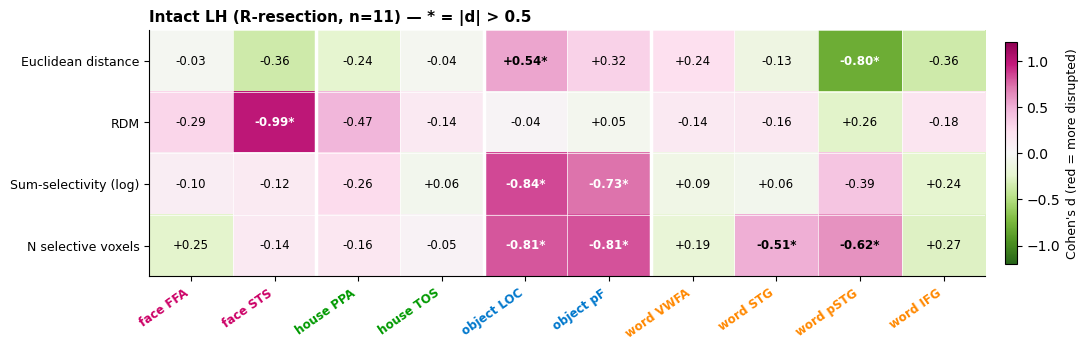

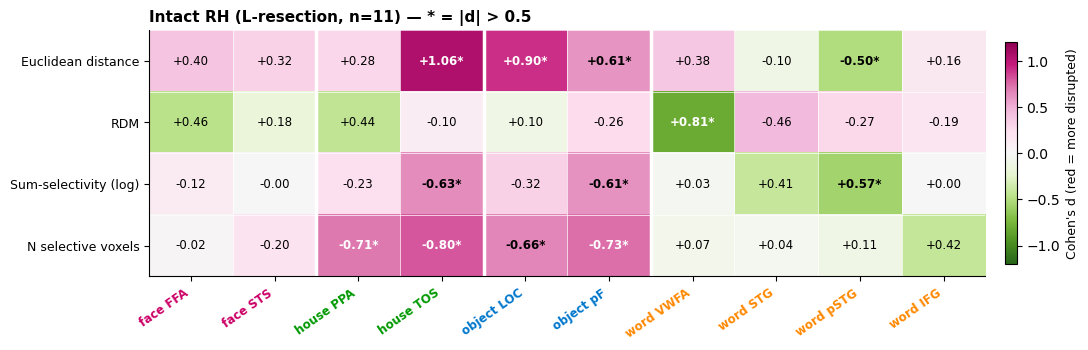

In [10]:
import matplotlib.colors as mcolors

ALL_ROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
MEASURES = ['distance', 'distinct', 'sum_sel', 'n_voxels']
MEASURE_LABELS = {'distance': 'Euclidean distance',
                  'distinct': 'RDM',
                  'sum_sel':  'Sum-selectivity (log)',
                  'n_voxels': 'N selective voxels'}

# Need ctrl/pt MNI for distance (loaded above as mni_df; reuse)
ctrl = mni_df[mni_df['subject_id'].isin(ctrl_subs)].copy()
pt   = mni_df[mni_df['subject_id'].isin(otc_subs)].copy()

def _per_roi_volume(df, subs, roi, hemi):
    sub = df[(df['subject_id'].isin(subs)) & (df['category']==roi) &
             (df['hemi']==hemi)].drop_duplicates(subset=['subject_id'])
    vals = sub['sum_selec_norm'].dropna().values if 'sum_selec_norm' in df.columns else np.array([])
    vals = vals[vals > 0]
    return np.log10(vals) if len(vals) else np.array([])

def _per_roi_n_voxels(df, subs, roi, hemi):
    sub = df[(df['subject_id'].isin(subs)) & (df['category']==roi) &
             (df['hemi']==hemi)].drop_duplicates(subset=['subject_id'])
    vals = sub['volume'].dropna().values
    return vals[vals > 0]

def get_d_v2(intact, roi, measure):
    if measure == 'sum_sel':
        ct = _per_roi_volume(ctrl_le, ctrl_subs, roi, intact)
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v = _per_roi_volume(pt_le, pt_subs, roi, intact)
    elif measure == 'n_voxels':
        ct = _per_roi_n_voxels(ctrl_le, ctrl_subs, roi, intact)
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v = _per_roi_n_voxels(pt_le, pt_subs, roi, intact)
    elif measure == 'distinct':
        ct = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        pt_v = pt_le[(pt_le['subject_id'].isin(pt_subs)) & (pt_le['category']==roi) &
                     (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
    elif measure == 'distance':
        c = ctrl[(ctrl['category']==roi) & (ctrl['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        if len(c) < 3: return np.nan
        cen = c.mean(0)
        ct = np.array([np.linalg.norm(p-cen) for p in c])
        pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        p = pt[(pt['subject_id'].isin(pt_subs)) & (pt['category']==roi) &
               (pt['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna().values
        pt_v = np.array([np.linalg.norm(q-cen) for q in p])
    if len(ct) < 3 or len(pt_v) < 2: return np.nan
    return (pt_v.mean() - ct.mean()) / np.sqrt((pt_v.var(ddof=1) + ct.var(ddof=1))/2)

def color_value(d, measure):
    if measure in ('distinct', 'sum_sel', 'n_voxels'):
        return -d
    return d

roi_order = [r for cat in ALL_ROIS for r in ALL_ROIS[cat]]
roi_labels = [r.replace('_', ' ').replace('pSTG liu', 'pSTG') for r in roi_order]
cat_of = {r: cat for cat, rs in ALL_ROIS.items() for r in rs}
CAT_COLOR = {'face':'#cc0066', 'house':'#009900', 'object':'#0077cc', 'word':'#ff8800'}

def build_matrix(intact):
    M = np.full((len(MEASURES), len(roi_order)), np.nan)
    for j, roi in enumerate(roi_order):
        for i, meas in enumerate(MEASURES):
            M[i, j] = get_d_v2(intact, roi, meas)
    return M

vmax = 1.2
cmap = plt.cm.PiYG_r
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for intact, title in [('l', 'Intact LH (R-resection, n=11)'),
                      ('r', 'Intact RH (L-resection, n=11)')]:
    fig, ax = plt.subplots(figsize=(13, 3.2))
    M = build_matrix(intact)
    M_color = M.copy()
    for i, meas in enumerate(MEASURES):
        for j in range(M.shape[1]):
            M_color[i, j] = color_value(M[i, j], meas)
    im = ax.imshow(M_color, cmap=cmap, norm=norm, aspect='auto')

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isnan(v):
                ax.text(j, i, 'NA', ha='center', va='center', fontsize=8, color='gray')
            else:
                txt = f'{v:+.2f}' + ('*' if abs(v) > 0.5 else '')
                cv = M_color[i, j]
                color = 'white' if abs(cv) > 0.7 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=color,
                        fontweight='bold' if abs(v) > 0.5 else 'normal')

    ax.set_xticks(np.arange(len(roi_order)))
    ax.set_xticklabels(roi_labels, rotation=35, ha='right', fontsize=8.5)
    for tick, roi in zip(ax.get_xticklabels(), roi_order):
        tick.set_color(CAT_COLOR[cat_of[roi]])
        tick.set_fontweight('bold')
    ax.set_yticks(np.arange(len(MEASURES)))
    ax.set_yticklabels([MEASURE_LABELS[m] for m in MEASURES], fontsize=9)
    ax.set_title(f"{title} — * = |d| > 0.5", fontsize=11, fontweight='bold', loc='left')

    boundaries = np.cumsum([len(ALL_ROIS[c]) for c in ALL_ROIS])[:-1] - 0.5
    for b in boundaries:
        ax.axvline(b, color='white', lw=2.5)
    ax.set_xticks(np.arange(-0.5, len(roi_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(MEASURES), 1), minor=True)
    ax.grid(which='minor', color='white', lw=0.5)
    ax.tick_params(which='minor', length=0)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.9, pad=0.02)
    cbar.set_label("Cohen's d (red = more disrupted)", fontsize=9)
    plt.show()


## 6. Fig 3D — distinctiveness boxplot (face → house → object → word order)

Per-ROI Fisher-z distinctiveness. Bilateral ROIs split by hemi; word ROIs pooled (ctrl LH anchor). Order matches volume violin.


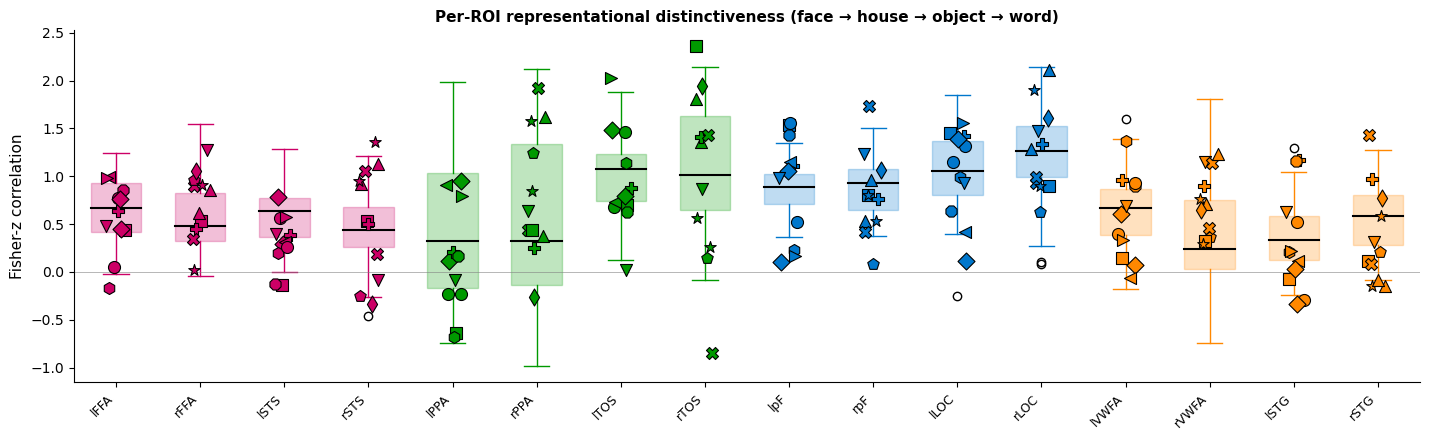

In [11]:
# ── Fig 3D — distinctiveness by ROI, face → house → object → word ───────────
ROI_ORDER = [
    ('face_FFA',  'l'),  ('face_FFA',  'r'),
    ('face_STS',  'l'),  ('face_STS',  'r'),
    ('house_PPA', 'l'),  ('house_PPA', 'r'),
    ('house_TOS', 'l'),  ('house_TOS', 'r'),
    ('object_pF', 'l'),  ('object_pF', 'r'),
    ('object_LOC','l'),  ('object_LOC','r'),
    ('word_VWFA', 'l'),  ('word_VWFA', 'r'),
    ('word_STG',  'l'),  ('word_STG',  'r'),
]

def pt_panel_match(sub, hspec):
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: return False, None
    return pt_h == hspec, pt_h

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    return f'{hspec}{s}'

ROI_CAT_COLOR = {
    'face_FFA':   '#cc0066', 'face_STS':   '#cc0066',
    'house_PPA':  '#009900', 'house_TOS':  '#009900',
    'object_pF':  '#0077cc', 'object_LOC': '#0077cc',
    'word_VWFA':  '#ff8800', 'word_STG':   '#ff8800',
}

_mc = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'p', 'h', '<', '>', '8', 'd']
PT_MARKERS = {s: _mc[i % len(_mc)] for i, s in enumerate(otc_subs)}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

n = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(14, n * 0.9), 4.5))
rng_d = np.random.RandomState(42)
JITTER = 0.12

for xi, (roi, hspec) in enumerate(ROI_ORDER):
    color = ROI_CAT_COLOR[roi]
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)] \
            ['liu_distinctiveness'].dropna().values
    if len(cvals) == 0: continue
    ax.boxplot(cvals, positions=[xi], widths=0.6, patch_artist=True,
               medianprops={'color': 'black', 'lw': 1.5},
               whiskerprops={'color': color}, capprops={'color': color},
               boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})
    for sub in otc_subs:
        ok, pt_h = pt_panel_match(sub, hspec)
        if not ok: continue
        val = get_distinct(pt_le, sub, roi, pt_h)
        if np.isnan(val): continue
        ax.scatter(xi + rng_d.uniform(-JITTER, JITTER), val,
                   marker=PT_MARKERS[sub], s=75, zorder=5,
                   edgecolors='black', linewidth=0.8, facecolors=color)

ax.set_xticks(np.arange(n))
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Fisher-z correlation', fontsize=11)
ax.axhline(0, color='gray', lw=0.4)
ax.set_title('Per-ROI representational distinctiveness (face → house → object → word)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

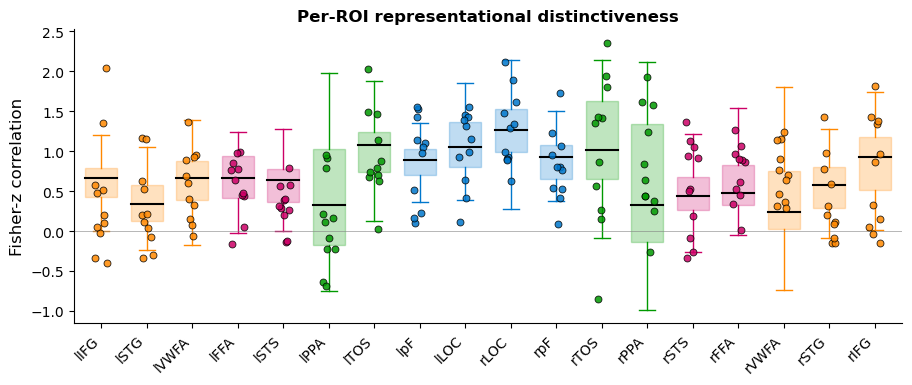

In [12]:
# ── Fig 3D — distinctiveness by ROI, face → house → object → word ───────────
ROI_ORDER = [
    ('word_IFG',  'l'),  ('word_STG',  'l'),  ('word_VWFA', 'l'),
    ('face_FFA',  'l'),  ('face_STS',  'l'),
    ('house_PPA', 'l'),  ('house_TOS', 'l'),
    ('object_pF', 'l'),  ('object_LOC','l'),
    ('object_LOC','r'),  ('object_pF', 'r'),
    ('house_TOS', 'r'),  ('house_PPA', 'r'),
    ('face_STS',  'r'),  ('face_FFA',  'r'),
    ('word_VWFA', 'r'),  ('word_STG',  'r'),  ('word_IFG',  'r'),
]

def pt_panel_match(sub, hspec):
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: return False, None
    return pt_h == hspec, pt_h

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    return f'{hspec}{s}'

ROI_CAT_COLOR = {
    'face_FFA':   '#cc0066', 'face_STS':   '#cc0066',
    'house_PPA':  '#009900', 'house_TOS':  '#009900',
    'object_pF':  '#0077cc', 'object_LOC': '#0077cc',
    'word_VWFA':  '#ff8800', 'word_STG':   '#ff8800',
    'word_IFG':   '#ff8800',
}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

n = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(9, n * 0.42), 4.2))
rng_d = np.random.RandomState(42)
JITTER = 0.15

for xi, (roi, hspec) in enumerate(ROI_ORDER):
    color = ROI_CAT_COLOR[roi]
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)] \
                ['liu_distinctiveness'].dropna().values
    if len(cvals) == 0: continue
    ax.boxplot(cvals, positions=[xi], widths=0.7, patch_artist=True,
               showfliers=False,
               medianprops={'color': 'black', 'lw': 1.5},
               whiskerprops={'color': color}, capprops={'color': color},
               boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})

    for sub in otc_subs:
        ok, pt_h = pt_panel_match(sub, hspec)
        if not ok: continue
        val = get_distinct(pt_le, sub, roi, pt_h)
        if np.isnan(val): continue
        ax.scatter(xi + rng_d.uniform(-JITTER, JITTER), val,
                   marker='o', s=25, zorder=5,
                   edgecolors='black', linewidth=0.6, facecolors=color, alpha=0.85)

ax.set_xticks(np.arange(n))
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER],
                   rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Fisher-z correlation', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.axhline(0, color='gray', lw=0.4)
ax.set_title('Per-ROI representational distinctiveness',
             fontsize=12, fontweight='bold')

ax.set_xlim(-0.6, n - 0.4)
ax.margins(x=0.005)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(left=0.07, right=0.99, top=0.92, bottom=0.22)
plt.show()

## Headline

Three measures of reorganization, three (mostly) independent stories:

| Measure | LH-intact (R-res) | RH-intact (L-res) |
|---|---|---|
| Distance | house, object | word (VWFA) |
| Volume | object loses | — |
| RDM | face (STS) | word (VWFA) |

- Distance does not predict RDM (ρ=−0.09, n.s.)
- Volume does not explain RDM (key hits strengthen when covaried)
- Convergence only in RH word_VWFA: anatomic + representational disruption co-occur when primary hemisphere is lost


In [13]:
for roi in ['house_PPA', 'house_TOS']:
    for h in ['l', 'r']:
        d = ctrl[(ctrl['category']==roi)&(ctrl['hemi']==h)]
        if len(d):
            print(f'{roi} {h}: x_sd={d["peak_x_mni"].std():.1f}, y_sd={d["peak_y_mni"].std():.1f}, n={len(d)}')

house_PPA l: x_sd=9.3, y_sd=20.4, n=282
house_PPA r: x_sd=8.3, y_sd=21.2, n=282
house_TOS l: x_sd=5.7, y_sd=5.8, n=282
house_TOS r: x_sd=4.4, y_sd=5.3, n=282


In [14]:
# ── Distance: Crawford t + deviation count + raw mm ─────────────────────────
mni_df = pd.read_csv(MNI_CSV)

def get_dist(sub, roi, hemi, df):
    s = df[(df['subject_id']==sub)&(df['category']==roi)&(df['hemi']==hemi)] \
        [['peak_x_mni','peak_y_mni']].dropna().values
    return s[0] if len(s) else None

print(f'{"Group":12s} {"ROI":18s} {"ctrl_mm":>9s} {"pt_mm":>9s} {"n_devnt":>8s} {"crit_t":>7s}')
print('-'*70)
for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    for roi in ALL_ROIS_FLAT:
        c = mni_df[mni_df['subject_id'].isin(ctrl_subs)&(mni_df['category']==roi)&
                   (mni_df['hemi']==intact)][['peak_x_mni','peak_y_mni']].dropna() \
                  .drop_duplicates().values
        if len(c)<3: continue
        cen = c.mean(0)
        ct_d = np.linalg.norm(c-cen, axis=1)
        ct_hi = np.percentile(ct_d, 97.5)
        pt_d, n_dev, n_t = [], 0, 0
        for sub in pt_subs:
            p = get_dist(sub, roi, intact, mni_df)
            if p is None: continue
            d = np.linalg.norm(p-cen)
            pt_d.append(d); n_t += 1
            if d > ct_hi: n_dev += 1
        if not pt_d: continue
        # Mean Crawford t
        ts = [crawford(d, ct_d)[0] for d in pt_d]
        ts = [t for t in ts if not np.isnan(t)]
        crit = float(tdist.ppf(0.975, df=len(ct_d)-1))
        n_crit = sum(1 for t in ts if abs(t)>crit)
        print(f'{label:12s} {roi:18s} {ct_d.mean():9.1f} {np.mean(pt_d):9.1f} '
              f'{n_dev}/{n_t}    {n_crit}/{n_t}')

Group        ROI                  ctrl_mm     pt_mm  n_devnt  crit_t
----------------------------------------------------------------------
LH (R-res)   face_FFA                 9.4       8.7 0/11    0/11
LH (R-res)   face_STS                13.9      12.4 0/11    1/11
LH (R-res)   house_PPA               21.7      21.3 1/11    2/11
LH (R-res)   house_TOS                6.7       6.1 0/11    0/11
LH (R-res)   object_LOC               6.7       9.1 3/11    3/11
LH (R-res)   object_pF                7.3       8.4 1/11    2/11
LH (R-res)   word_VWFA               11.2       9.2 0/11    0/11
LH (R-res)   word_STG                15.4      15.0 1/11    1/11
LH (R-res)   word_pSTG_liu           12.5       9.1 0/11    2/11
LH (R-res)   word_IFG                11.6      10.9 0/11    0/11
RH (L-res)   face_FFA                 8.5      11.6 1/11    2/11
RH (L-res)   face_STS                14.3      17.5 2/11    2/11
RH (L-res)   house_PPA               21.9      23.5 2/11    0/11
RH (L-res)   ho

In [15]:
# ── RDM: permutation test on group mean per ROI × hemi ─────────────────────
N_PERM = 10000
rng = np.random.RandomState(42)

print(f'{"Group":12s} {"ROI":18s} {"ctrl":>7s} {"pt":>7s} {"Δ":>7s} {"p_perm":>8s}')
print('-'*60)
for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
    pt_subs = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    for roi in ALL_ROIS_FLAT:
        ct = ctrl_le[(ctrl_le['category']==roi)&(ctrl_le['hemi']==intact)] \
             ['liu_distinctiveness'].dropna().values
        pt = pt_le[(pt_le['subject_id'].isin(pt_subs))&(pt_le['category']==roi)&
                   (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
        if len(ct)<3 or len(pt)<2: continue
        obs = pt.mean() - ct.mean()
        pool = np.concatenate([ct, pt])
        n_pt = len(pt)
        null = np.empty(N_PERM)
        for i in range(N_PERM):
            perm = rng.permutation(pool)
            null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
        p = (np.abs(null) >= abs(obs)).mean()
        flag = '*' if p<0.05 else ''
        print(f'{label:12s} {roi:18s} {ct.mean():7.2f} {pt.mean():7.2f} '
              f'{obs:+7.2f} {p:8.4f} {flag}')

Group        ROI                   ctrl      pt       Δ   p_perm
------------------------------------------------------------


LH (R-res)   face_FFA              0.67    0.57   -0.10   0.3784 
LH (R-res)   face_STS              0.61    0.32   -0.29   0.0076 *
LH (R-res)   house_PPA             0.44    0.12   -0.32   0.2134 
LH (R-res)   house_TOS             1.03    0.96   -0.07   0.6574 
LH (R-res)   object_LOC            1.05    1.03   -0.02   0.9158 
LH (R-res)   object_pF             0.87    0.89   +0.02   0.8604 
LH (R-res)   word_VWFA             0.64    0.57   -0.06   0.6686 
LH (R-res)   word_STG              0.37    0.30   -0.07   0.6309 
LH (R-res)   word_pSTG_liu         0.34    0.47   +0.13   0.3969 
LH (R-res)   word_IFG              0.62    0.51   -0.11   0.4238 
RH (L-res)   face_FFA              0.55    0.72   +0.17   0.1834 
RH (L-res)   face_STS              0.45    0.54   +0.09   0.5240 
RH (L-res)   house_PPA             0.50    0.83   +0.33   0.2288 
RH (L-res)   house_TOS             1.11    1.03   -0.08   0.7426 
RH (L-res)   object_LOC            1.23    1.28   +0.05   0.7821 
RH (L-res

In [16]:
sub_info = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
age_map = sub_info.drop_duplicates('sub').set_index('sub')['age']

# LI based on volume (count of suprathreshold voxels) instead of peak_z
ct_l_vol = ctrl_le[(ctrl_le['category']=='word_VWFA')&(ctrl_le['hemi']=='l')] \
           .drop_duplicates('subject_id').set_index('subject_id')['volume']
ct_r_vol = ctrl_le[(ctrl_le['category']=='word_VWFA')&(ctrl_le['hemi']=='r')] \
           .drop_duplicates('subject_id').set_index('subject_id')['volume']
common = ct_l_vol.index.intersection(ct_r_vol.index)
li_vol = (ct_l_vol.loc[common] - ct_r_vol.loc[common]) / (ct_l_vol.loc[common] + ct_r_vol.loc[common] + 1)
print(f'Volume-based LI: LH-dom {(li_vol>0.2).sum()}, bilateral {(li_vol.abs()<=0.2).sum()}, RH-dom {(li_vol<-0.2).sum()}')
print(f'Mean LI: {li_vol.mean():+.3f}, median: {li_vol.median():+.3f}')

Volume-based LI: LH-dom 15, bilateral 15, RH-dom 8
Mean LI: +0.092, median: +0.094


In [17]:
# ── VWFA lateralization with cluster threshold (≥5 contiguous voxels) ───────
from scipy.ndimage import label
from scipy.stats import norm
import nibabel as nib
from pathlib import Path

MIN_CLUSTER = 5
SEL_Z = float(norm.ppf(0.99))  # ≈2.326

# word_VWFA contrast: cope 13 (Face>Word), negated → Word>Face
COPE, NEGATE = 13, True

def vol_clustered(sid, ses, hemi, min_cluster=MIN_CLUSTER):
    """Count voxels in suprathreshold clusters of size >= min_cluster within searchmask."""
    sm_path = Path(processed_dir) / sid / f'ses-{ses:02d}' / 'ROIs' / f'{hemi}_word_VWFA_searchmask.nii.gz'
    if not sm_path.exists(): return np.nan
    feat = Path(processed_dir) / sid / f'ses-{ses:02d}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'
    zf = feat / f'cope{COPE}.feat' / 'stats' / 'zstat1.nii.gz'
    if not zf.exists(): return np.nan
    sm = nib.load(sm_path).get_fdata() > 0
    z = nib.load(zf).get_fdata()
    if NEGATE: z = -z
    supra = (z > SEL_Z) & sm
    labeled, n = label(supra)
    if n == 0: return 0
    sizes = np.bincount(labeled.ravel())[1:]
    return int(sizes[sizes >= min_cluster].sum())

# Get first session per control
ctrl_ses = ctrl_le.groupby('subject_id')['ses_num'].min().to_dict()

vol_l, vol_r = {}, {}
for s in ctrl_subs:
    ses = ctrl_ses.get(s)
    if ses is None: continue
    vol_l[s] = vol_clustered(s, int(ses), 'l')
    vol_r[s] = vol_clustered(s, int(ses), 'r')

vol_l = pd.Series(vol_l).dropna()
vol_r = pd.Series(vol_r).dropna()
common = vol_l.index.intersection(vol_r.index)

li_clust = (vol_l.loc[common] - vol_r.loc[common]) / (vol_l.loc[common] + vol_r.loc[common] + 1)
print(f'Cluster-thresholded volume LI (min cluster = {MIN_CLUSTER} voxels):')
print(f'  LH-dom (LI > +0.2):  {(li_clust>0.2).sum()}')
print(f'  Bilateral (|LI|≤0.2): {(li_clust.abs()<=0.2).sum()}')
print(f'  RH-dom (LI < −0.2):  {(li_clust<-0.2).sum()}')
print(f'\nMean LI: {li_clust.mean():+.3f}, median: {li_clust.median():+.3f}')
print(f'\nVolumes: LH mean={vol_l.loc[common].mean():.0f}, RH mean={vol_r.loc[common].mean():.0f}')
print(f'Subjects with 0 voxels in either hemi: {((vol_l.loc[common]==0) | (vol_r.loc[common]==0)).sum()}')

Cluster-thresholded volume LI (min cluster = 5 voxels):
  LH-dom (LI > +0.2):  15
  Bilateral (|LI|≤0.2): 16
  RH-dom (LI < −0.2):  7

Mean LI: +0.092, median: +0.093

Volumes: LH mean=1023, RH mean=900
Subjects with 0 voxels in either hemi: 4


In [18]:
li_age = pd.DataFrame({'li': li_clust, 'age': [age_map.get(s) for s in li_clust.index]}).dropna()
rho, p_s = spearmanr(li_age['age'], li_age['li'])
r, p_p = pearsonr(li_age['age'], li_age['li'])
print(f'n={len(li_age)}: Spearman ρ={rho:+.3f}, p={p_s:.3f} | Pearson r={r:+.3f}, p={p_p:.3f}')

NameError: name 'pearsonr' is not defined

In [ ]:
young = li_age[li_age['age'] < 14]
old = li_age[li_age['age'] >= 14]
print(f'<14 (n={len(young)}): mean LI={young["li"].mean():+.3f}, '
      f'LH-dom={(young["li"]>0.2).sum()}, bilat={(young["li"].abs()<=0.2).sum()}, RH-dom={(young["li"]<-0.2).sum()}')
print(f'≥14 (n={len(old)}): mean LI={old["li"].mean():+.3f}, '
      f'LH-dom={(old["li"]>0.2).sum()}, bilat={(old["li"].abs()<=0.2).sum()}, RH-dom={(old["li"]<-0.2).sum()}')
from scipy.stats import ttest_ind
t, p = ttest_ind(old['li'], young['li'], equal_var=False)
print(f'\nWelch t={t:+.2f}, p={p:.3f}')

<14 (n=19): mean LI=+0.186, LH-dom=10, bilat=6, RH-dom=3
≥14 (n=19): mean LI=-0.002, LH-dom=5, bilat=10, RH-dom=4

Welch t=-1.27, p=0.211


In [ ]:
adult_subs = li_age[li_age['age'] >= 18].index.tolist()
print(f'Cutting {len(adult_subs)} ctrls aged ≥18: {adult_subs}')

li_ped = li_age[li_age['age'] < 18]['li']
print(f'\nPediatric ctrls only (n={len(li_ped)}):')
print(f'  LH-dom (LI > +0.2):  {(li_ped>0.2).sum()}')
print(f'  Bilateral (|LI|≤0.2): {(li_ped.abs()<=0.2).sum()}')
print(f'  RH-dom (LI < −0.2):  {(li_ped<-0.2).sum()}')
print(f'  Mean LI: {li_ped.mean():+.3f}')

Cutting 9 ctrls aged ≥18: ['sub-001', 'sub-043', 'sub-057', 'sub-084', 'sub-087', 'sub-093', 'sub-095', 'sub-096', 'sub-097']

Pediatric ctrls only (n=29):
  LH-dom (LI > +0.2):  12
  Bilateral (|LI|≤0.2): 11
  RH-dom (LI < −0.2):  6
  Mean LI: +0.093


In [ ]:
print('Patient ages:')
pt_ages = sub_info[sub_info['sub'].isin(otc_subs)].drop_duplicates('sub')[['sub','age']]
print(pt_ages.sort_values('age').to_string(index=False))
print(f'\nMean: {pt_ages["age"].mean():.1f}, range: [{pt_ages["age"].min():.1f}, {pt_ages["age"].max():.1f}]')
print(f'Patients ≥18: {(pt_ages["age"]>=18).sum()}/{len(pt_ages)}')

Patient ages:
    sub   age
sub-077  7.80
sub-004  7.81
sub-099 11.54
sub-075 11.58
sub-069 12.16
sub-044 12.48
sub-010 12.80
sub-074 13.05
sub-021 13.30
sub-008 14.78
sub-090 15.58
sub-108 16.05
sub-076 16.07
sub-079 16.65
sub-066 16.81
sub-039 17.02
sub-089 18.29
sub-005 19.42
sub-092 19.78
sub-082 20.46
sub-078 22.22
sub-091 37.26

Mean: 16.0, range: [7.8, 37.3]
Patients ≥18: 6/22
